In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
ROLL_NUMBER = 56
np.random.seed(ROLL_NUMBER)
sales_data = np.random.randint(1000, 5001, size=(12, 4))
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df = pd.DataFrame(sales_data, columns=columns, index=months)
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,4925,3532,1399,4264
Feb,2442,2259,2146,1654
Mar,1233,2019,1087,3070
Apr,1356,2465,4418,4383
May,1879,1369,3712,4212
Jun,3754,1254,3347,4083
Jul,3926,3128,1757,2766
Aug,1929,4673,3826,3335
Sep,3204,1677,2525,4490
Oct,4855,3716,2113,4603


The random seed is set using the roll number. Monthly sales data for four product categories is generated using NumPy with values between 1000 and 5000. The data is then converted into a Pandas DataFrame with months as the index for further analysis.

In [2]:
df.head(), df.describe()

(     Electronics  Clothing  Home & Kitchen  Sports
 Jan         4925      3532            1399    4264
 Feb         2442      2259            2146    1654
 Mar         1233      2019            1087    3070
 Apr         1356      2465            4418    4383
 May         1879      1369            3712    4212,
        Electronics     Clothing  Home & Kitchen       Sports
 count    12.000000    12.000000       12.000000    12.000000
 mean   2653.666667  2656.916667     2475.333333  3817.583333
 std    1427.958258  1096.269580     1086.902215   928.712644
 min    1069.000000  1254.000000     1087.000000  1654.000000
 25%    1335.000000  1890.750000     1714.250000  3268.750000
 50%    2185.500000  2362.000000     2129.500000  4174.500000
 75%    3797.000000  3578.000000     3438.250000  4409.750000
 max    4925.000000  4673.000000     4418.000000  4814.000000)

In [3]:
total_sales_category = df.sum()
total_sales_month = df.sum(axis=1)
total_sales_category, total_sales_month

(Electronics       31844
 Clothing          31883
 Home & Kitchen    29704
 Sports            45811
 dtype: int64,
 Jan    14120
 Feb     8501
 Mar     7409
 Apr    12622
 May    11172
 Jun    12438
 Jul    11577
 Aug    13763
 Sep    11896
 Oct    15287
 Nov     8754
 Dec    11703
 dtype: int64)

In [4]:
growth_per_category = df.pct_change().mean()
growth_per_category

,0
Electronics,0.055234
Clothing,0.206205
Home & Kitchen,0.265819
Sports,0.083555


In [5]:
df["Total Sales"] = df.sum(axis=1)
df["Growth Rate"] = df["Total Sales"].pct_change() * 100
df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,4925,3532,1399,4264,14120,NaN
Feb,2442,2259,2146,1654,8501,-39.794618
Mar,1233,2019,1087,3070,7409,-12.845548
Apr,1356,2465,4418,4383,12622,70.360373
May,1879,1369,3712,4212,11172,-11.487878
Jun,3754,1254,3347,4083,12438,11.331901
Jul,3926,3128,1757,2766,11577,-6.922335
Aug,1929,4673,3826,3335,13763,18.882267
Sep,3204,1677,2525,4490,11896,-13.565356
Oct,4855,3716,2113,4603,15287,28.505380


In [6]:
df_discounted = df.copy()
if ROLL_NUMBER % 2 == 0:
    df_discounted["Electronics"] = df_discounted["Electronics"] * 0.9
    discount_applied = "10% discount applied to Electronics"
else:
    df_discounted["Clothing"] = df_discounted["Clothing"] * 0.85
    discount_applied = "15% discount applied to Clothing"
discount_applied, df_discounted.head()

('10% discount applied to Electronics',
      Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
 Jan       4432.5      3532            1399    4264        14120          NaN
 Feb       2197.8      2259            2146    1654         8501   -39.794618
 Mar       1109.7      2019            1087    3070         7409   -12.845548
 Apr       1220.4      2465            4418    4383        12622    70.360373
 May       1691.1      1369            3712    4212        11172   -11.487878)

From cell 5-9, here computed total sales, growth rates,and also applied discounts based on whether the roll number is even or odd.

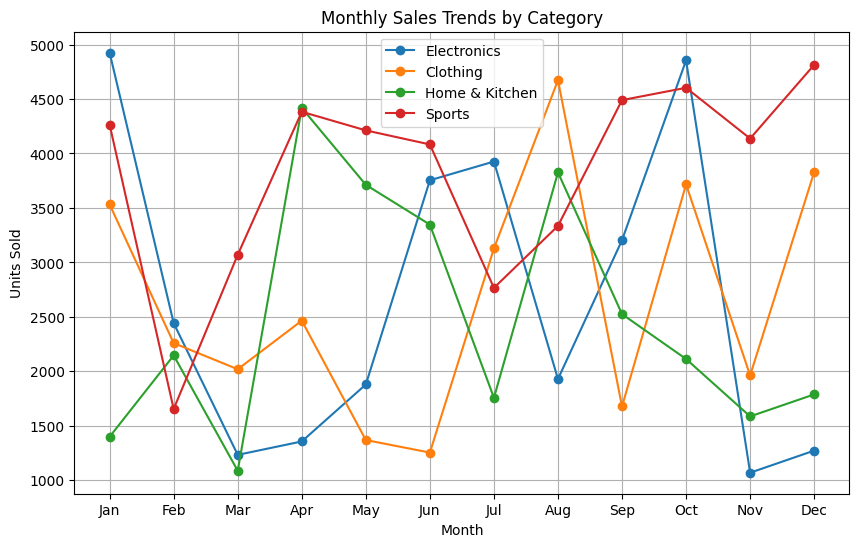

In [7]:
plt.figure(figsize=(10,6))
for col in ["Electronics", "Clothing", "Home & Kitchen", "Sports"]:
    plt.plot(df.index, df[col], marker='o', label=col)
plt.title("Monthly Sales Trends by Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

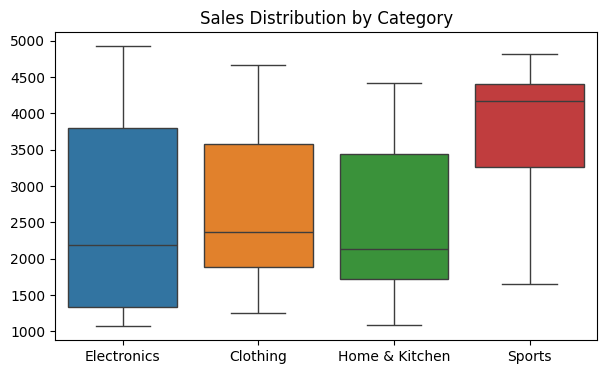

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]])
plt.title("Sales Distribution by Category")
plt.show()

In cell 9, the line plot shows trends over months, while in the cell 11, the box plot shows the distribution and variability of sales across categories.

In [10]:
array = np.array([[1, -2, 3], [-4, 5, -6]])
abs_array = np.abs(array)
percentiles_flat = np.percentile(array.flatten(), [25, 50, 75])
percentiles_col = np.percentile(array, [25, 50, 75], axis=0)
percentiles_row = np.percentile(array, [25, 50, 75], axis=1)
mean_flat = np.mean(array)
median_flat = np.median(array)
std_flat = np.std(array)
mean_col = np.mean(array, axis=0)
median_col = np.median(array, axis=0)
std_col = np.std(array, axis=0)
mean_row = np.mean(array, axis=1)
median_row = np.median(array, axis=1)
std_row = np.std(array, axis=1)
abs_array, percentiles_flat, percentiles_col, percentiles_row, mean_flat, median_flat, std_flat

(array([[1, 2, 3],
        [4, 5, 6]]),
 array([-3.5, -0.5,  2.5]),
 array([[-2.75, -0.25, -3.75],
        [-1.5 ,  1.5 , -1.5 ],
        [-0.25,  3.25,  0.75]]),
 array([[-0.5, -5. ],
        [ 1. , -4. ],
        [ 2. ,  0.5]]),
 np.float64(-0.5),
 np.float64(-0.5),
 np.float64(3.8622100754188224))

In cell 12, element-wise absolute values, percentiles, mean, median and standard deviation are computed for the given NumPy array. These values are calculated for the flattened array as well as for the rows and columns to analyze data distribution and variability.

In [11]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
floor_vals = np.floor(a)
ceil_vals = np.ceil(a)
trunc_vals = np.trunc(a)
round_vals = np.round(a)
floor_vals, ceil_vals, trunc_vals, round_vals

(array([-2., -2., -1.,  0.,  1.,  1.,  3.]),
 array([-1., -1., -0.,  1.,  2.,  2.,  3.]),
 array([-1., -1., -0.,  0.,  1.,  1.,  3.]),
 array([-2., -2., -0.,  0.,  2.,  2.,  3.]))

In [12]:
lst = [10, 20, 30, 40]
i, j = 1, 3
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp
lst


[10, 40, 30, 20]

In [13]:
s = {10, 20, 30, 40}
lst = list(s)
i, j = 0, 2
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp
s_swapped = set(lst)
s_swapped

{10, 20, 30, 40}